In [ ]:

import os
import numpy as np
import pandas as pd
import cv2
from google.colab import drive
import matplotlib.pyplot as plt
from PIL import Image
import time


drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[INFO] Using model already loaded in session.
[INFO] Last conv layer used for Grad-CAM: conv2d


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_307']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


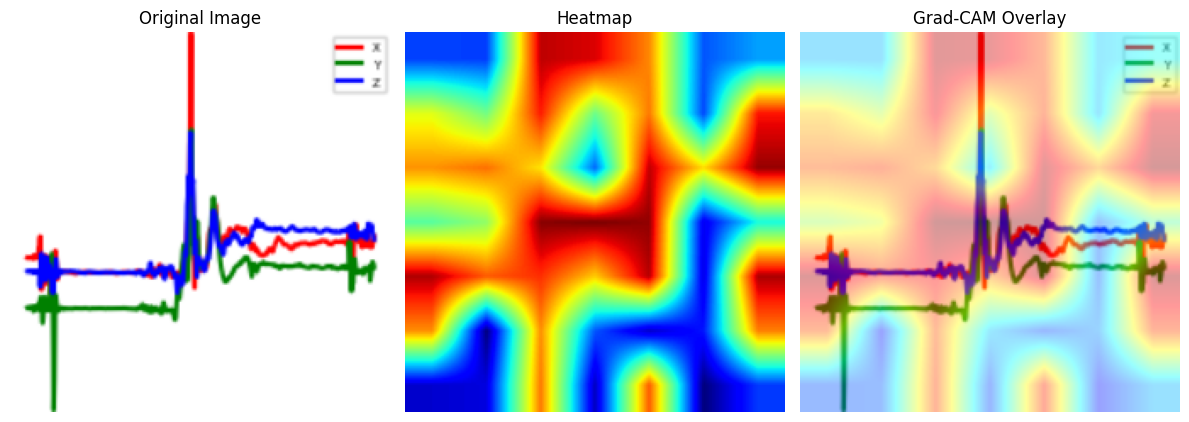

[INFO] Grad-CAM image saved at 300 dpi -> gradcam_superimposed_300dpi.png


In [ ]:

# -*- coding: utf-8 -*-
# Grad-CAM for a single chosen image

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

# ----------------- CONFIG -----------------
image_path = "/content/drive/MyDrive/imgchuteclasse2/img_0000_Accelerometer_0s.png"
IMG_SIZE = (224, 224)
last_conv_layer_name = None

# ----------------- Load model -----------------
try:
    model
    print("[INFO] Using model already loaded in session.")
except NameError:
    model_path = "fall_detection_experience2_model.keras"
    if os.path.exists(model_path):
        print(f"[INFO] Loading model from '{model_path}'...")
        model = tf.keras.models.load_model(model_path)
    else:
        raise RuntimeError("No model found in session and 'fall_detection_experience2_model.keras' is missing.")

# ----------------- Preprocess image -----------------
def load_and_preprocess(img_path, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    return x, img

img_array, pil_img = load_and_preprocess(image_path, IMG_SIZE)

# ----------------- Detect last conv layer -----------------
if last_conv_layer_name is None:
    last_conv = None
    for layer in reversed(model.layers):
        if 'Conv2D' in layer.__class__.__name__ or 'conv' in layer.name.lower():
            try:
                if len(layer.output_shape) == 4:
                    last_conv = layer.name
                    break
            except Exception:
                last_conv = layer.name
                break
    if last_conv is None:
        raise RuntimeError("Could not automatically find a Conv2D layer.")
    last_conv_layer_name = last_conv

print(f"[INFO] Last conv layer used for Grad-CAM: {last_conv_layer_name}")

# ----------------- Grad-CAM function -----------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_for_class=1):
    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if predictions.shape[-1] == 1:
            loss = predictions[:, 0]
        else:
            if pred_for_class is None:
                pred_index = tf.argmax(predictions[0])
            else:
                pred_index = pred_for_class
            loss = predictions[:, pred_index]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap.numpy(), 0)
    max_val = heatmap.max() if heatmap.max() != 0 else 1e-10
    heatmap /= max_val
    return heatmap

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_for_class=1)

# ----------------- Overlay and save at 300 dpi -----------------
img_bgr = cv2.imread(image_path)
img_bgr = cv2.resize(img_bgr, IMG_SIZE)
heatmap_resized = cv2.resize(heatmap, (img_bgr.shape[1], img_bgr.shape[0]))
heatmap_uint8 = np.uint8(255 * heatmap_resized)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
superimposed_img = cv2.addWeighted(img_bgr, 0.6, heatmap_color, 0.4, 0)

# ----------------- Display -----------------
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].set_title("Original Image")
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

axes[1].set_title("Heatmap")
axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].axis("off")

axes[2].set_title("Grad-CAM Overlay")
axes[2].imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
axes[2].axis("off")

plt.tight_layout()
plt.savefig("gradcam_superimposed_300dpi.png", dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Grad-CAM image saved at 300 dpi -> gradcam_superimposed_300dpi.png")

[INFO] Using model already loaded in session.


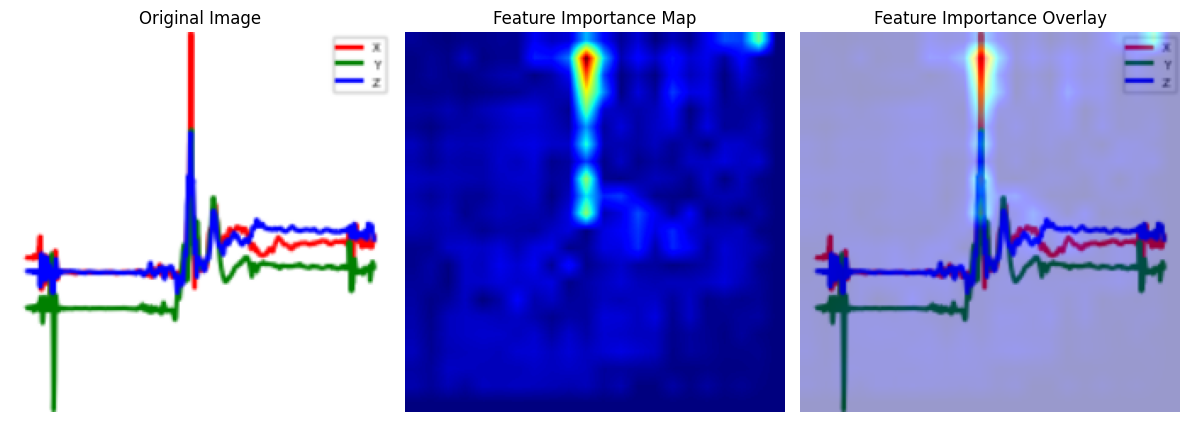

[INFO] Feature Importance Map image saved at 300 dpi -> feature_importance_map_300dpi.png


In [ ]:

# -*- coding: utf-8 -*-
# Feature Importance Map (Perturbation-Based) avec chemin d'image spécifique

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# ----------------- CONFIG -----------------
# Lien direct vers ton image dans Google Drive
chosen_path = "/content/drive/MyDrive/imgchuteclasse2/img_0000_Accelerometer_0s.png"

IMG_SIZE = (224, 224)
patch_size = 20      # Taille du patch à perturber
stride = 10          # Pas pour le balayage

# ----------------- Load Model -----------------
try:
    model
    print("[INFO] Using model already loaded in session.")
except NameError:
    model_path = "fall_detection_experience2_model.keras"
    if os.path.exists(model_path):
        print(f"[INFO] Loading model from '{model_path}'...")
        model = tf.keras.models.load_model(model_path)
    else:
        raise RuntimeError("No model found in session and 'fall_detection_experience2_model.keras' is missing.")

# ----------------- Preprocess Image -----------------
def load_and_preprocess(img_path, target_size=IMG_SIZE):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    return x, img

img_array, pil_img = load_and_preprocess(chosen_path, IMG_SIZE)

# ----------------- Feature Importance Map Function -----------------
def feature_importance_map(img_array, model, patch_size=20, stride=10):
    h, w = img_array.shape[1:3]
    output = np.zeros((h//stride, w//stride))
    base_pred = model.predict(img_array, verbose=0)[0][0]  # Base score pour la classe 0 (fall)
    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            perturbed = img_array.copy()
            perturbed[0, i:i+patch_size, j:j+patch_size, :] = 0
            pred = model.predict(perturbed, verbose=0)[0][0]
            output[i//stride, j//stride] = abs(base_pred - pred)
    max_val = output.max() if output.max() != 0 else 1e-10
    output /= max_val
    return output

importance_map = feature_importance_map(img_array, model, patch_size, stride)

# ----------------- Overlay and Save at 300 dpi -----------------
img_bgr = cv2.imread(chosen_path)
img_bgr = cv2.resize(img_bgr, IMG_SIZE)

importance_resized = cv2.resize(importance_map, (img_bgr.shape[1], img_bgr.shape[0]))
importance_uint8 = np.uint8(255 * importance_resized)
importance_color = cv2.applyColorMap(importance_uint8, cv2.COLORMAP_JET)

superimposed_img = cv2.addWeighted(img_bgr, 0.6, importance_color, 0.4, 0)

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes[0].set_title("Original Image")
axes[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
axes[0].axis("off")

axes[1].set_title("Feature Importance Map")
axes[1].imshow(importance_resized, cmap='jet')
axes[1].axis("off")

axes[2].set_title("Feature Importance Overlay")
axes[2].imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
axes[2].axis("off")

plt.tight_layout()
plt.savefig("feature_importance_map_300dpi.png", dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Feature Importance Map image saved at 300 dpi -> feature_importance_map_300dpi.png")